data_slip.shape=(869, 290)
time_slip.shape=(869,)
data_no_slip.shape=(149, 290)
time_no_slip.shape=(149,)
data_non_contact.shape=(839, 290)
time_non_contact.shape=(839,)


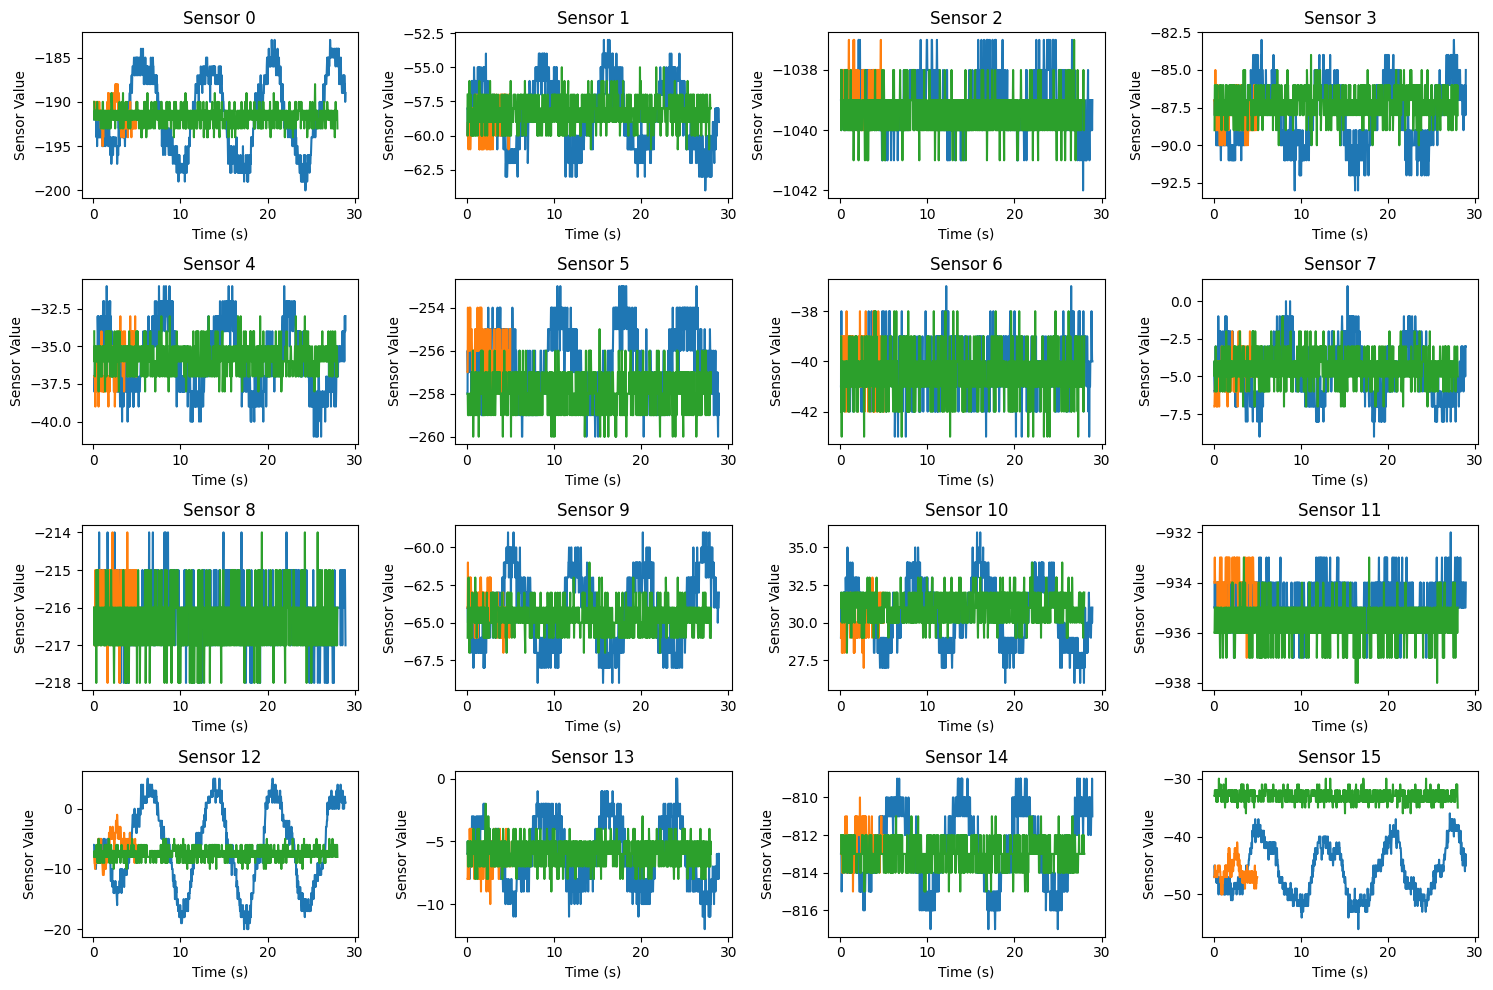

In [2]:
import os
import csv
import time
import numpy as np

base_drive = "G:\\" if os.path.exists("G:\\") else "D:\\"
data_path = os.path.join(base_drive, "datasets", "tac2Slip", "severity-03-15")
classes = ['salt-no-slip', 'salt', 'non-contact']


def import_csv(file_path):
    with open(file_path, 'r') as f:
        reader = csv.reader(f)
        #skip header
        next(reader)
        data = []
        for row in reader:
            data.append([float(i) for i in row])
    data = np.array(data, dtype=np.float32)
    time = data[:, 0]
    data = data[:, 1:]
    return time, data

c = 1
i = 0
file_path = os.path.join(data_path, classes[1], f"tactile_data{i:04d}.csv")
time_slip, data_slip = import_csv(file_path)

print(f"{data_slip.shape=}")
print(f"{time_slip.shape=}")

file_path = os.path.join(data_path, classes[0], f"tactile_data{i:04d}.csv")
time_no_slip, data_no_slip = import_csv(file_path)
print(f"{data_no_slip.shape=}")
print(f"{time_no_slip.shape=}")

file_path = os.path.join(data_path, classes[2], f"tactile_data{i:04d}.csv")
time_non_contact, data_non_contact = import_csv(file_path)
print(f"{data_non_contact.shape=}")
print(f"{time_non_contact.shape=}")

# --------------------------- Plot first 16 channels across time -------------------------- #
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for j in range(16):
    ax = axs[j // 4, j % 4]
    ax.plot(time_slip, data_slip[:, j])
    ax.plot(time_no_slip, data_no_slip[:, j])
    ax.plot(time_non_contact, data_non_contact[:, j])
    ax.set_title(f'Sensor {j}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Sensor Value')
plt.tight_layout()
plt.show()

In [3]:
# import lstm_model.pth

import torch
import sys

path1 = r"D:\\UNI\\Studentermedhjaelper\\slip_severity"
path2 = r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity"
path = path1 if os.path.exists(path1) else path2

sys.path.append(path)
from src.LSTM import LSTMModel
import sys


model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=3)
model.load_state_dict(torch.load(os.path.join(path, "lstm_model.pth"), map_location=torch.device('cpu')))
# model.load_state_dict(torch.load(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\lstm_model.pth", map_location=torch.device('cpu')))
model.eval()
print(f"{data_slip.shape=}")
X = torch.from_numpy(data_slip).unsqueeze(0)[:,:, :51]  # shape (1, seq_len, 51)
Y_pose = torch.from_numpy(data_slip).unsqueeze(0)[:,:, 255:255+3]  # shape (1, seq_len, 3)
# take first order difference of Y to get the change in slip severity
dt = torch.from_numpy(np.diff(time_slip).astype(np.float32)).view(1, -1, 1)
Y = torch.diff(Y_pose, dim=1) / dt
time_slip_trimmed = time_slip[1:]
X = X[:, 1:, :]  # remove the first time step to match the shape of Y
print(f"{X.shape=}, {Y.shape=}")

pred = []
with torch.no_grad():
    for i in range(X.shape[1]):
        if i < 20:
            x_i = X[:, :i+1, :] 
        else:
            x_i = X[:, i-20:i+1, :]  # shape (1, 21, 51)
        # print(f"{x_i.shape=}")

        pred_i = model(x_i/1024)
        # print(f"{pred_i=}")
        pred.append(pred_i)

pred = torch.stack(pred, dim=1)  # shape (1, seq_len, 3)
print(f"{pred.shape=}")



data_slip.shape=(869, 290)
X.shape=torch.Size([1, 868, 51]), Y.shape=torch.Size([1, 868, 3])
pred.shape=torch.Size([1, 868, 3])


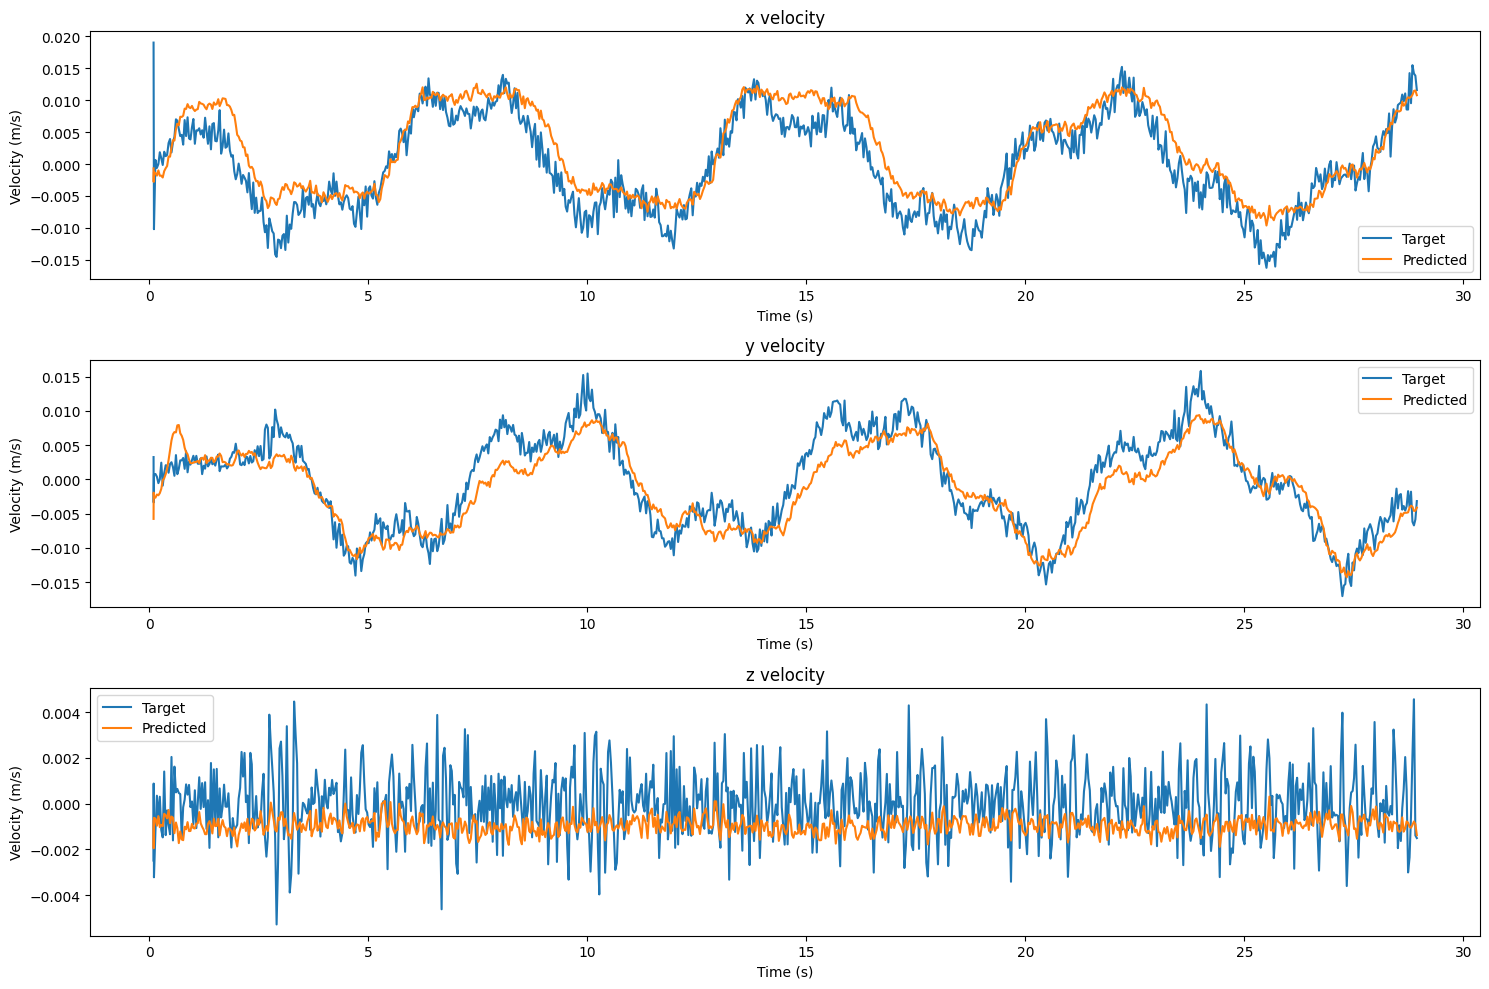

In [4]:
# plot predictions vs targets for each class across time
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

class_LUT = {0: "x", 1: "y", 2: "z"}
for j in range(3):
    ax = axs[j]
    ax.plot(time_slip_trimmed, Y[0, :, j].numpy(), label='Target')
    ax.plot(time_slip_trimmed, pred[0, :, j].numpy(), label='Predicted')
    ax.set_title(f'{class_LUT[j]} velocity')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
plt.tight_layout()
plt.show()

63 63
43 43


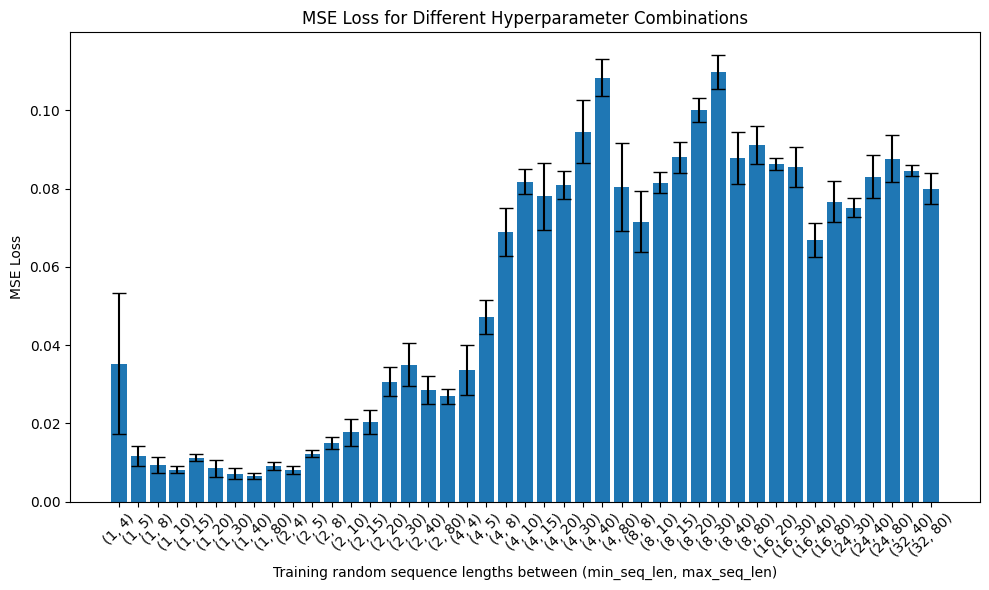

In [13]:
# ---------------------------------------------------------------------------- #
#                        PLOT OF MSE FOR PARAMETER SWEEP                       #
# ---------------------------------------------------------------------------- #
nan = "nan"
loss_dict={(1, 4): [0.05382377112453634, 0.06012919274243442, 0.025783700953153046, 0.0209622879258611, 0.015853937334296377], (1, 5): [0.012402488299730148, 0.011037449775771662, 0.007290823131122373, 0.015491691417992115, 0.012226154265755957], (1, 8): [0.012564135461368343, 0.006868350107900121, 0.009443033952265978, 0.007628244093873284, 0.010832938365638256], (1, 10): [0.007551602553576231, 0.008623278403485363, 0.006958869201215831, 0.00854020273651589, 0.009341414213519205], (1, 15): [0.01100219769234007, 0.011112279935993931, 0.009872523305768316, 0.011805106039074335, 0.012424229644238949], (1, 20): [0.012412223202938383, 0.009516702372242104, 0.007381935476918112, 0.00576931991699067, 0.007450251924720677], (1, 30): [0.008451578630642458, 0.007481678473678502, 0.00882592306218364, 0.005517782071943988, 0.005595925623889674], (1, 40): [0.0056993966414169836, 0.006791027918965979, 0.005861435530029915, 0.00767862508920106, 0.007292749635367231], (1, 80): [0.008176555052738298, 0.009426322553984144, 0.01073530087755485, 0.0089509209448641, 0.007983408063988794], (2, 4): [0.007089019202711907, 0.008903042286295782, 0.007306581024419178, 0.007879220287908207, 0.00981148886917667], (2, 5): [0.01087638409808278, 0.013015159659764984, 0.012986686842685396, 0.012950779023495588, 0.011481558438390493], (2, 8): [0.01311340851878578, 0.013499305414205248, 0.017387617379426956, 0.01478545189919797, 0.016206375661898743], (2, 10): [0.015607457692650232, 0.02092566823756153, 0.01598270863971927, 0.013577417174184864, 0.022730124352330513], (2, 15): [0.01471711898391897, 0.01896878374232487, 0.0227771672335538, 0.022504963404075665, 0.02278446617790244], (2, 20): [0.026845024559985508, 0.029023799706589092, 0.0275676478208466, 0.03630321218886159, 0.03376829200847582], (2, 30): [0.02997898208824071, 0.04296846687793732, 0.03991942768069831, 0.02913442931391976, 0.03295767730609937], (2, 40): [0.03429179012098096, 0.028947828676212917, 0.02897160237824375, 0.027580468153411693, 0.02291209547018463], (2, 80): [0.030619289895350284, 0.02516479790210724, 0.026011911644177002, 0.02582139242440462, 0.02722257189452648], (4, 4): [0.02705547357486053, 0.02928874133662744, 0.03263700871982358, 0.03365945274179632, 0.04546688361601396], (4, 5): [0.0396345950324427, 0.049931886182589966, 0.04580311900512739, 0.05244122411717068, 0.048296387900005684], (4, 8): [0.06425830586390062, 0.061418403278697624, 0.0666001784530553, 0.07769820805300366, 0.07423225722529671], (4, 10): [0.07782179354266687, 0.08356583660299127, 0.08102038875222206, 0.08691102063113992, 0.07944614135406235], (4, 15): [0.08319417929107492, 0.08719175139611418, 0.08278767222707922, 0.06354746798222716, 0.07323481007055803], (4, 20): [0.079818571833047, 0.0798405185341835, 0.08688531206412749, 0.0756061930548061, 0.08238055049018427], (4, 30): [0.09462146596475081, 0.08320696076208894, 0.08812135322527452, 0.10322876680981029, 0.10324404727328908], (4, 40): [0.10227871483022516, 0.10956845703450116, 0.11284229227087715, 0.10311779244379564, 0.11367839100685986], (4, 80): [0.06828419830311429, 0.09823434258049185, 0.07886159894141284, 0.06921468641270291, 0.08736831017515877], (8, 4): [], (8, 5): [], (8, 8): [0.06462949785319241, 0.060453558510000054, 0.07440475509925322, 0.07904491099444302, 0.07932049510153857], (8, 10): [0.07808931612155655, 0.07946635681119832, 0.0811424312943762, 0.08593812449411913, 0.08287334476004947], (8, 15): [0.08536159145561131, 0.08660862425511534, 0.08312218128280206, 0.09374430267648264, 0.09080792760307138], (8, 20): [0.0970741838894107, 0.09612636539069089, 0.10441661355170337, 0.10154559260064905, 0.10116628015583212], (8, 30): [0.11446657099507072, 0.10858175564895976, 0.10667708583853462, 0.10381069169803099, 0.1152138655835932], (8, 40): [0.09711303765123541, 0.0823600021275607, 0.08306659995154901, 0.09470832957462831, 0.08201982995325868], (8, 80): [0.09294790402054787, 0.08242522688074545, 0.09152353351766412, 0.09103055366060951, 0.0973639650778337], (16, 4): [], (16, 5): [], (16, 8): [], (16, 10): [], (16, 15): [], (16, 20): [0.08471590415997939, 0.08641325750134209, 0.08907881785522807, 0.08521410789002072, 0.08590896224433725], (16, 30): [0.07945173233747482, 0.0898131670599634, 0.081165650351481, 0.09320479021830992, 0.08399601856415922], (16, 40): [0.07281260361725633, 0.05930510874498974, 0.06718700717795979, 0.0671413628892465, 0.06739962338046594], (16, 80): [0.0685053061355244, 0.07755559987642548, 0.08261467516422272, 0.0815064778382128, 0.07299261235378006], (24, 4): [], (24, 5): [], (24, 8): [], (24, 10): [], (24, 15): [], (24, 20): [], (24, 30): [0.07817047089338303, 0.07647502998059447, 0.0742047679695216, 0.07086151296442206, 0.07563270865516229], (24, 40): [0.08817941695451736, 0.0721738263964653, 0.08553533425385301, 0.08500507812608372, 0.08439896323464134], (24, 80): [0.08474667878313498, 0.09359465403990312, 0.08625890856439417, 0.09479928829453209, 0.07894961671395735], (32, 4): [], (32, 5): [], (32, 8): [], (32, 10): [], (32, 15): [], (32, 20): [], (32, 30): [], (32, 40): [0.08512841029600664, 0.08662752129814842, 0.08502810956402258, 0.08246044780720364, 0.08377093483101238], (32, 80): [0.08275932920250026, 0.08238381486047398, 0.08344121751460162, 0.07802903381260959, 0.07304305380040949]}
loss_std_dict={(1, 4): np.float64(0.01807704421475727), (1, 5): np.float64(0.002646754130713055), (1, 8): np.float64(0.0020781055806147336), (1, 10): np.float64(0.0008436239202665605), (1, 15): np.float64(0.0008561011821302187), (1, 20): np.float64(0.002286816209764041), (1, 30): np.float64(0.0013920558823419362), (1, 40): np.float64(0.0007765943011444161), (1, 80): np.float64(0.0009891508972955185), (2, 4): np.float64(0.0010224008583698068), (2, 5): np.float64(0.0009050809279241876), (2, 8): np.float64(0.0016132817011230165), (2, 10): np.float64(0.0034643811637468714), (2, 15): np.float64(0.003165398529921432), (2, 20): np.float64(0.0036957408783477434), (2, 30): np.float64(0.005504244161473197), (2, 40): np.float64(0.003633997862802182), (2, 80): np.float64(0.0019430427906510512), (4, 4): np.float64(0.00637446903124998), (4, 5): np.float64(0.004366234733326334), (4, 8): np.float64(0.00614219987779108), (4, 10): np.float64(0.0032001329233877786), (4, 15): np.float64(0.008555371705312809), (4, 20): np.float64(0.003696814198043431), (4, 30): np.float64(0.008011031872202111), (4, 40): np.float64(0.004780786571226388), (4, 80): np.float64(0.011321584860895127), (8, 4): np.float64(nan), (8, 5): np.float64(nan), (8, 8): np.float64(0.007690593534265835), (8, 10): np.float64(0.0027378579598738005), (8, 15): np.float64(0.003835269332303314), (8, 20): np.float64(0.003059389915323256), (8, 30): np.float64(0.004431316925706031), (8, 40): np.float64(0.006631023498021043), (8, 80): np.float64(0.004859612720699199), (16, 4): np.float64(nan), (16, 5): np.float64(nan), (16, 8): np.float64(nan), (16, 10): np.float64(nan), (16, 15): np.float64(nan), (16, 20): np.float64(0.0015212086590137815), (16, 30): np.float64(0.005207568341079779), (16, 40): np.float64(0.0043115168379493345), (16, 80): np.float64(0.005285720870498614), (24, 4): np.float64(nan), (24, 5): np.float64(nan), (24, 8): np.float64(nan), (24, 10): np.float64(nan), (24, 15): np.float64(nan), (24, 20): np.float64(nan), (24, 30): np.float64(0.0024642911176187424), (24, 40): np.float64(0.005593221360059876), (24, 80): np.float64(0.005873846228247211), (32, 4): np.float64(nan), (32, 5): np.float64(nan), (32, 8): np.float64(nan), (32, 10): np.float64(nan), (32, 15): np.float64(nan), (32, 20): np.float64(nan), (32, 30): np.float64(nan), (32, 40): np.float64(0.0014027346802305864), (32, 80): np.float64(0.003934428843522092)}
print(len(loss_dict), len(loss_std_dict))
loss_std_dict = {k: v for k, v in loss_std_dict.items() if not np.isnan(v)}
loss_dict = {k: v for k, v in loss_dict.items() if k in loss_std_dict}
loss_mean_dict = {k: np.mean(v) for k, v in loss_dict.items()}

print(len(loss_dict), len(loss_std_dict))

# plot loss_dict with error bars from loss_std_dict
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(loss_dict))
y = [loss_mean_dict[k] for k in loss_dict.keys()]
ax.bar(x, y, yerr=[loss_std_dict[k] for k in loss_dict.keys()], capsize=5)
ax.set_xticks(x)
ax.set_xticklabels([f"({k[0]}, {k[1]})" for k in loss_dict.keys()], rotation=45)
ax.set_xlabel('Training random sequence lengths between (min_seq_len, max_seq_len)')
ax.set_ylabel('MSE Loss')
ax.set_title('MSE Loss for Different Hyperparameter Combinations')
plt.tight_layout()
plt.show()





In [ ]:
# ---------------------------------------------------------------------------- #
#                        PLOT OF MSE FOR PARAMETER SWEEP                       #
# ---------------------------------------------------------------------------- #
nan = "nan"
loss_dict={(1, 4): [0.05382377112453634, 0.06012919274243442, 0.025783700953153046, 0.0209622879258611, 0.015853937334296377], (1, 5): [0.012402488299730148, 0.011037449775771662, 0.007290823131122373, 0.015491691417992115, 0.012226154265755957], (1, 8): [0.012564135461368343, 0.006868350107900121, 0.009443033952265978, 0.007628244093873284, 0.010832938365638256], (1, 10): [0.007551602553576231, 0.008623278403485363, 0.006958869201215831, 0.00854020273651589, 0.009341414213519205], (1, 15): [0.01100219769234007, 0.011112279935993931, 0.009872523305768316, 0.011805106039074335, 0.012424229644238949], (1, 20): [0.012412223202938383, 0.009516702372242104, 0.007381935476918112, 0.00576931991699067, 0.007450251924720677], (1, 30): [0.008451578630642458, 0.007481678473678502, 0.00882592306218364, 0.005517782071943988, 0.005595925623889674], (1, 40): [0.0056993966414169836, 0.006791027918965979, 0.005861435530029915, 0.00767862508920106, 0.007292749635367231], (1, 80): [0.008176555052738298, 0.009426322553984144, 0.01073530087755485, 0.0089509209448641, 0.007983408063988794], (2, 4): [0.007089019202711907, 0.008903042286295782, 0.007306581024419178, 0.007879220287908207, 0.00981148886917667], (2, 5): [0.01087638409808278, 0.013015159659764984, 0.012986686842685396, 0.012950779023495588, 0.011481558438390493], (2, 8): [0.01311340851878578, 0.013499305414205248, 0.017387617379426956, 0.01478545189919797, 0.016206375661898743], (2, 10): [0.015607457692650232, 0.02092566823756153, 0.01598270863971927, 0.013577417174184864, 0.022730124352330513], (2, 15): [0.01471711898391897, 0.01896878374232487, 0.0227771672335538, 0.022504963404075665, 0.02278446617790244], (2, 20): [0.026845024559985508, 0.029023799706589092, 0.0275676478208466, 0.03630321218886159, 0.03376829200847582], (2, 30): [0.02997898208824071, 0.04296846687793732, 0.03991942768069831, 0.02913442931391976, 0.03295767730609937], (2, 40): [0.03429179012098096, 0.028947828676212917, 0.02897160237824375, 0.027580468153411693, 0.02291209547018463], (2, 80): [0.030619289895350284, 0.02516479790210724, 0.026011911644177002, 0.02582139242440462, 0.02722257189452648], (4, 4): [0.02705547357486053, 0.02928874133662744, 0.03263700871982358, 0.03365945274179632, 0.04546688361601396], (4, 5): [0.0396345950324427, 0.049931886182589966, 0.04580311900512739, 0.05244122411717068, 0.048296387900005684], (4, 8): [0.06425830586390062, 0.061418403278697624, 0.0666001784530553, 0.07769820805300366, 0.07423225722529671], (4, 10): [0.07782179354266687, 0.08356583660299127, 0.08102038875222206, 0.08691102063113992, 0.07944614135406235], (4, 15): [0.08319417929107492, 0.08719175139611418, 0.08278767222707922, 0.06354746798222716, 0.07323481007055803], (4, 20): [0.079818571833047, 0.0798405185341835, 0.08688531206412749, 0.0756061930548061, 0.08238055049018427], (4, 30): [0.09462146596475081, 0.08320696076208894, 0.08812135322527452, 0.10322876680981029, 0.10324404727328908], (4, 40): [0.10227871483022516, 0.10956845703450116, 0.11284229227087715, 0.10311779244379564, 0.11367839100685986], (4, 80): [0.06828419830311429, 0.09823434258049185, 0.07886159894141284, 0.06921468641270291, 0.08736831017515877], (8, 4): [], (8, 5): [], (8, 8): [0.06462949785319241, 0.060453558510000054, 0.07440475509925322, 0.07904491099444302, 0.07932049510153857], (8, 10): [0.07808931612155655, 0.07946635681119832, 0.0811424312943762, 0.08593812449411913, 0.08287334476004947], (8, 15): [0.08536159145561131, 0.08660862425511534, 0.08312218128280206, 0.09374430267648264, 0.09080792760307138], (8, 20): [0.0970741838894107, 0.09612636539069089, 0.10441661355170337, 0.10154559260064905, 0.10116628015583212], (8, 30): [0.11446657099507072, 0.10858175564895976, 0.10667708583853462, 0.10381069169803099, 0.1152138655835932], (8, 40): [0.09711303765123541, 0.0823600021275607, 0.08306659995154901, 0.09470832957462831, 0.08201982995325868], (8, 80): [0.09294790402054787, 0.08242522688074545, 0.09152353351766412, 0.09103055366060951, 0.0973639650778337], (16, 4): [], (16, 5): [], (16, 8): [], (16, 10): [], (16, 15): [], (16, 20): [0.08471590415997939, 0.08641325750134209, 0.08907881785522807, 0.08521410789002072, 0.08590896224433725], (16, 30): [0.07945173233747482, 0.0898131670599634, 0.081165650351481, 0.09320479021830992, 0.08399601856415922], (16, 40): [0.07281260361725633, 0.05930510874498974, 0.06718700717795979, 0.0671413628892465, 0.06739962338046594], (16, 80): [0.0685053061355244, 0.07755559987642548, 0.08261467516422272, 0.0815064778382128, 0.07299261235378006], (24, 4): [], (24, 5): [], (24, 8): [], (24, 10): [], (24, 15): [], (24, 20): [], (24, 30): [0.07817047089338303, 0.07647502998059447, 0.0742047679695216, 0.07086151296442206, 0.07563270865516229], (24, 40): [0.08817941695451736, 0.0721738263964653, 0.08553533425385301, 0.08500507812608372, 0.08439896323464134], (24, 80): [0.08474667878313498, 0.09359465403990312, 0.08625890856439417, 0.09479928829453209, 0.07894961671395735], (32, 4): [], (32, 5): [], (32, 8): [], (32, 10): [], (32, 15): [], (32, 20): [], (32, 30): [], (32, 40): [0.08512841029600664, 0.08662752129814842, 0.08502810956402258, 0.08246044780720364, 0.08377093483101238], (32, 80): [0.08275932920250026, 0.08238381486047398, 0.08344121751460162, 0.07802903381260959, 0.07304305380040949]}
loss_std_dict={(1, 4): np.float64(0.01807704421475727), (1, 5): np.float64(0.002646754130713055), (1, 8): np.float64(0.0020781055806147336), (1, 10): np.float64(0.0008436239202665605), (1, 15): np.float64(0.0008561011821302187), (1, 20): np.float64(0.002286816209764041), (1, 30): np.float64(0.0013920558823419362), (1, 40): np.float64(0.0007765943011444161), (1, 80): np.float64(0.0009891508972955185), (2, 4): np.float64(0.0010224008583698068), (2, 5): np.float64(0.0009050809279241876), (2, 8): np.float64(0.0016132817011230165), (2, 10): np.float64(0.0034643811637468714), (2, 15): np.float64(0.003165398529921432), (2, 20): np.float64(0.0036957408783477434), (2, 30): np.float64(0.005504244161473197), (2, 40): np.float64(0.003633997862802182), (2, 80): np.float64(0.0019430427906510512), (4, 4): np.float64(0.00637446903124998), (4, 5): np.float64(0.004366234733326334), (4, 8): np.float64(0.00614219987779108), (4, 10): np.float64(0.0032001329233877786), (4, 15): np.float64(0.008555371705312809), (4, 20): np.float64(0.003696814198043431), (4, 30): np.float64(0.008011031872202111), (4, 40): np.float64(0.004780786571226388), (4, 80): np.float64(0.011321584860895127), (8, 4): np.float64(nan), (8, 5): np.float64(nan), (8, 8): np.float64(0.007690593534265835), (8, 10): np.float64(0.0027378579598738005), (8, 15): np.float64(0.003835269332303314), (8, 20): np.float64(0.003059389915323256), (8, 30): np.float64(0.004431316925706031), (8, 40): np.float64(0.006631023498021043), (8, 80): np.float64(0.004859612720699199), (16, 4): np.float64(nan), (16, 5): np.float64(nan), (16, 8): np.float64(nan), (16, 10): np.float64(nan), (16, 15): np.float64(nan), (16, 20): np.float64(0.0015212086590137815), (16, 30): np.float64(0.005207568341079779), (16, 40): np.float64(0.0043115168379493345), (16, 80): np.float64(0.005285720870498614), (24, 4): np.float64(nan), (24, 5): np.float64(nan), (24, 8): np.float64(nan), (24, 10): np.float64(nan), (24, 15): np.float64(nan), (24, 20): np.float64(nan), (24, 30): np.float64(0.0024642911176187424), (24, 40): np.float64(0.005593221360059876), (24, 80): np.float64(0.005873846228247211), (32, 4): np.float64(nan), (32, 5): np.float64(nan), (32, 8): np.float64(nan), (32, 10): np.float64(nan), (32, 15): np.float64(nan), (32, 20): np.float64(nan), (32, 30): np.float64(nan), (32, 40): np.float64(0.0014027346802305864), (32, 80): np.float64(0.003934428843522092)}
print(len(loss_dict), len(loss_std_dict))
loss_std_dict = {k: v for k, v in loss_std_dict.items() if not np.isnan(v)}
loss_dict = {k: v for k, v in loss_dict.items() if k in loss_std_dict}
loss_mean_dict = {k: np.mean(v) for k, v in loss_dict.items()}

print(len(loss_dict), len(loss_std_dict))

# plot loss_dict with error bars from loss_std_dict
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(loss_dict))
y = [loss_mean_dict[k] for k in loss_dict.keys()]
first_key_vals = [k[0] for k in loss_dict.keys()]
unique_first_key_vals = sorted(set(first_key_vals))
color_map = {v: plt.cm.tab10(i % 10) for i, v in enumerate(unique_first_key_vals)}
bar_colors = [color_map[v] for v in first_key_vals]
#no colours:

ax.bar(
    x,
    y,
    yerr=[loss_std_dict[k] for k in loss_dict.keys()],
    capsize=5,
    color=bar_colors
)

ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=color_map[v], label=f"{v}") for v in unique_first_key_vals],
    title="First key value"
)
ax.set_xticks(x)
ax.set_xticklabels([f"({k[0]}, {k[1]})" for k in loss_dict.keys()], rotation=45)
ax.set_xlabel('Training random sequence lengths between (min_seq_len, max_seq_len)')
ax.set_ylabel('MSE Loss')
ax.set_title('MSE Loss for Different Hyperparameter Combinations')
plt.tight_layout()
plt.show()





data_slip.shape=(869, 290)
X.shape=torch.Size([1, 868, 51]), Y.shape=torch.Size([1, 868, 3])
pred.shape=torch.Size([1, 868, 3])


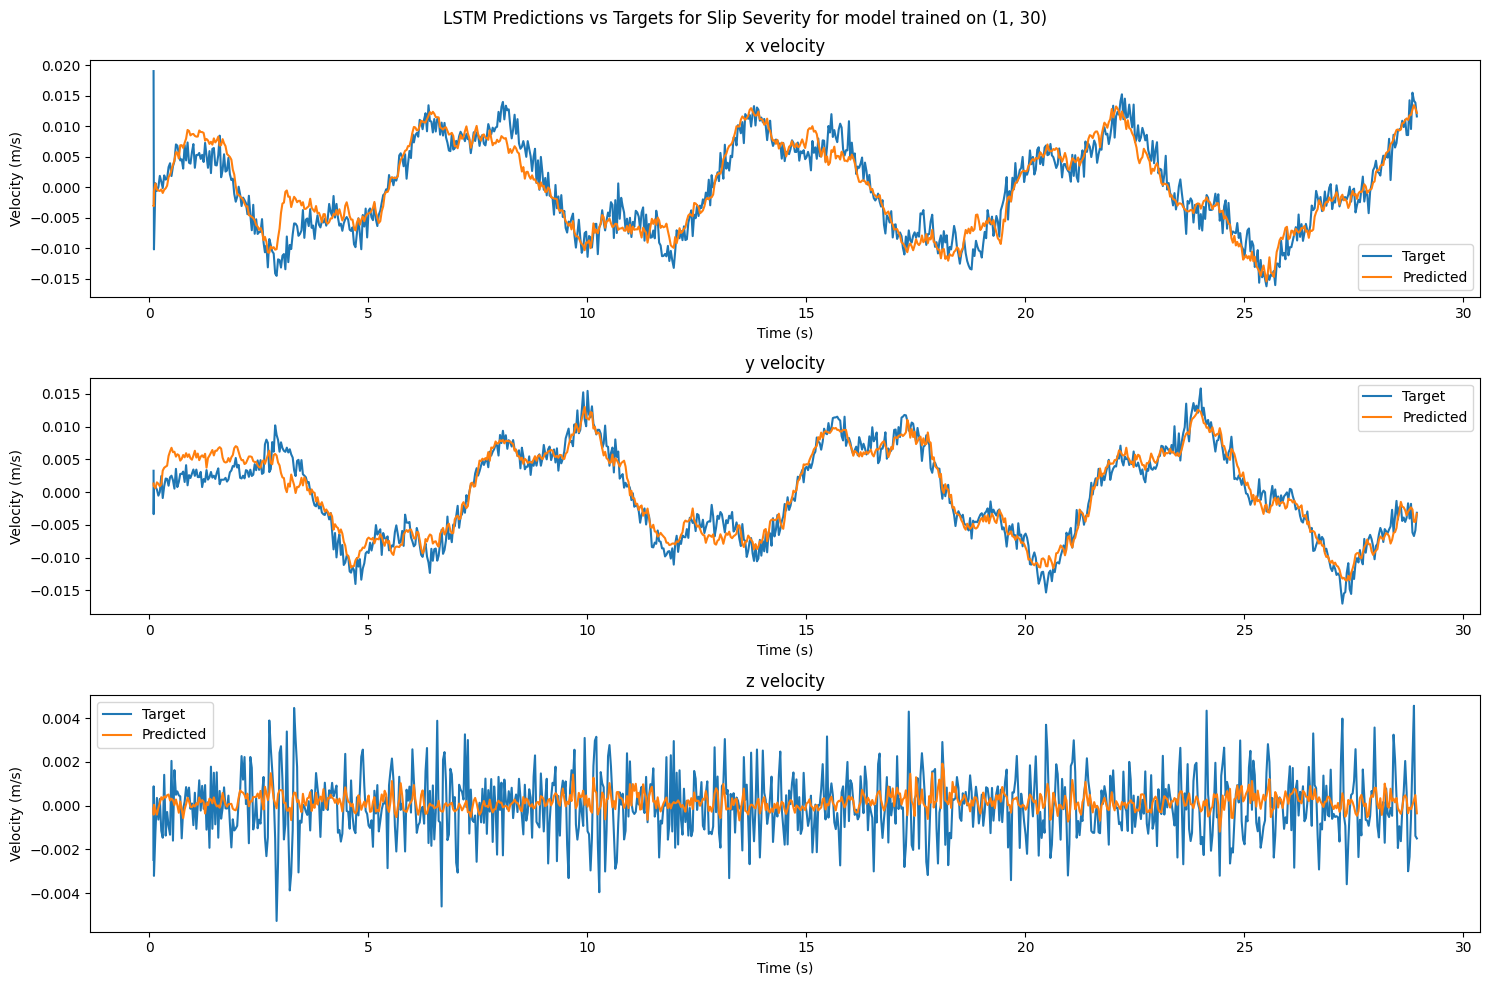

In [17]:
model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=3)
model.load_state_dict(torch.load(os.path.join(path, "lstm_model_1-30.pth"), map_location=torch.device('cpu')))
# model.load_state_dict(torch.load(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\lstm_model.pth", map_location=torch.device('cpu')))
model.eval()
print(f"{data_slip.shape=}")
X = torch.from_numpy(data_slip).unsqueeze(0)[:,:, :51]  # shape (1, seq_len, 51)
Y_pose = torch.from_numpy(data_slip).unsqueeze(0)[:,:, 255:255+3]  # shape (1, seq_len, 3)
# take first order difference of Y to get the change in slip severity
dt = torch.from_numpy(np.diff(time_slip).astype(np.float32)).view(1, -1, 1)
Y = torch.diff(Y_pose, dim=1) / dt
time_slip_trimmed = time_slip[1:]
X = X[:, 1:, :]  # remove the first time step to match the shape of Y
print(f"{X.shape=}, {Y.shape=}")

pred = []
with torch.no_grad():
    for i in range(X.shape[1]):
        if i < 20:
            x_i = X[:, :i+1, :] 
        else:
            x_i = X[:, i-20:i+1, :]  # shape (1, 21, 51)
        # print(f"{x_i.shape=}")

        pred_i = model(x_i/1024)
        # print(f"{pred_i=}")
        pred.append(pred_i)

pred = torch.stack(pred, dim=1)  # shape (1, seq_len, 3)
print(f"{pred.shape=}")
# plot predictions vs targets for each class across time
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

class_LUT = {0: "x", 1: "y", 2: "z"}
for j in range(3):
    ax = axs[j]
    ax.plot(time_slip_trimmed, Y[0, :, j].numpy(), label='Target')
    ax.plot(time_slip_trimmed, pred[0, :, j].numpy(), label='Predicted')
    ax.set_title(f'{class_LUT[j]} velocity')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
plt.suptitle('LSTM Predictions vs Targets for Slip Severity for model trained on (1, 30)')
plt.tight_layout()
plt.show()

data_slip.shape=(869, 290)
X.shape=torch.Size([1, 868, 51]), Y.shape=torch.Size([1, 868, 3])
pred.shape=torch.Size([1, 868, 3])


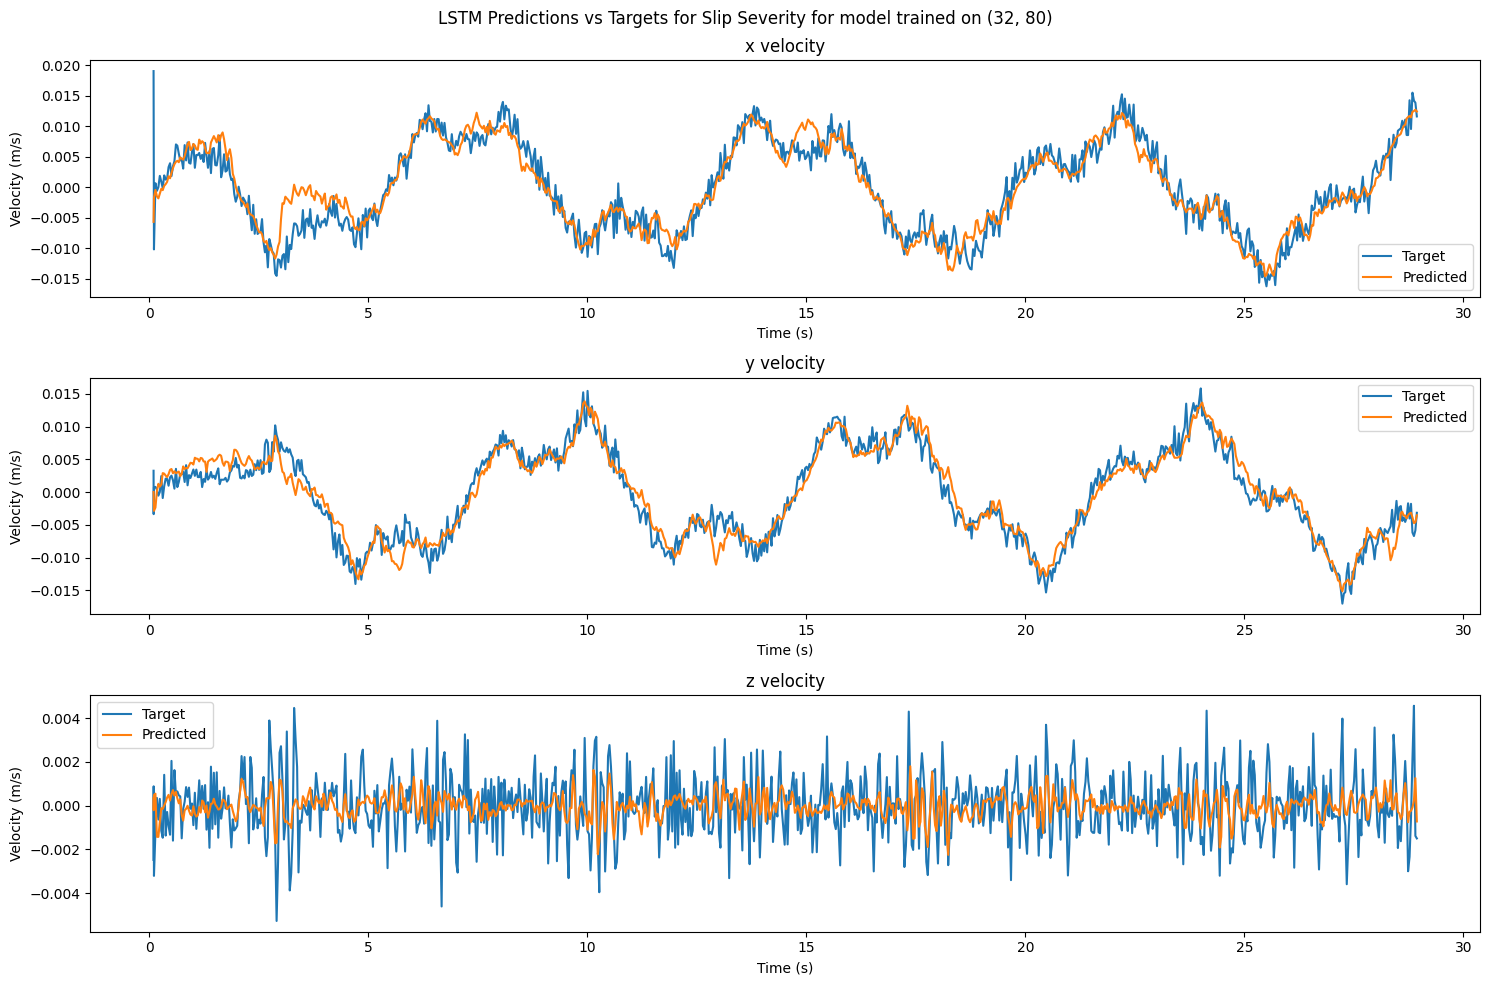

In [22]:
model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=3)
model.load_state_dict(torch.load(os.path.join(path, "lstm_model_32-80.pth"), map_location=torch.device('cpu')))
# model.load_state_dict(torch.load(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\lstm_model.pth", map_location=torch.device('cpu')))
model.eval()
print(f"{data_slip.shape=}")
X = torch.from_numpy(data_slip).unsqueeze(0)[:,:, :51]  # shape (1, seq_len, 51)
Y_pose = torch.from_numpy(data_slip).unsqueeze(0)[:,:, 255:255+3]  # shape (1, seq_len, 3)
# take first order difference of Y to get the change in slip severity
dt = torch.from_numpy(np.diff(time_slip).astype(np.float32)).view(1, -1, 1)
Y = torch.diff(Y_pose, dim=1) / dt
time_slip_trimmed = time_slip[1:]
X = X[:, 1:, :]  # remove the first time step to match the shape of Y
print(f"{X.shape=}, {Y.shape=}")

pred = []
with torch.no_grad():
    for i in range(X.shape[1]):
        if i < 20:
            x_i = X[:, :i+1, :] 
        else:
            x_i = X[:, i-20:i+1, :]  # shape (1, 21, 51)
        # print(f"{x_i.shape=}")

        pred_i = model(x_i/1024)
        # print(f"{pred_i=}")
        pred.append(pred_i)

pred = torch.stack(pred, dim=1)  # shape (1, seq_len, 3)
print(f"{pred.shape=}")
# plot predictions vs targets for each class across time
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

class_LUT = {0: "x", 1: "y", 2: "z"}
for j in range(3):
    ax = axs[j]
    ax.plot(time_slip_trimmed, Y[0, :, j].numpy(), label='Target')
    ax.plot(time_slip_trimmed, pred[0, :, j].numpy(), label='Predicted')
    ax.set_title(f'{class_LUT[j]} velocity')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
plt.suptitle('LSTM Predictions vs Targets for Slip Severity for model trained on (32, 80)')
plt.tight_layout()
plt.show()